# 10 · EDA and sanity checks (spec §4.4)
Day-1 HRES forecast vs IMD observed, land-only subdivision means, for three subdivisions. If they do not visibly track, alignment or units are wrong.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
from purva_netra.labels import add_log_error
t = add_log_error(pd.read_parquet('../data/processed/table.parquet'))
import json
names = {f['properties']['rid']: f['properties']['name'] for f in json.load(open('../configs/regions/imd_subdivisions.geojson'))['features']}
print('period', t.init.min(), '→', t.init.max(), '| inits', t.init.nunique(), '| rows', len(t))

period 2020-07-01 00:00:00 → 2020-07-31 12:00:00 | inits 62 | rows 22320


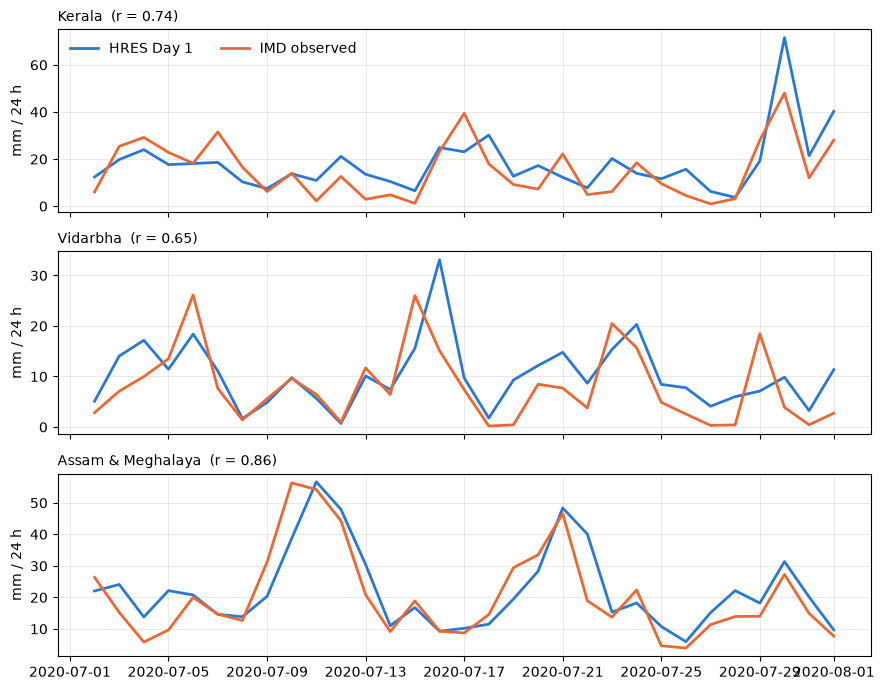

In [2]:
sel = [30, 8, 11]   # Kerala, Vidarbha, Assam & Meghalaya
d1 = t[(t.lead == 1) & (t.init.dt.hour == 0)]
fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, r in zip(axs, sel):
    s = d1[d1.rid == r].sort_values('valid_date')
    ax.plot(s.valid_date, s.f_rain, color='#2a78d6', lw=2, label='HRES Day 1')
    ax.plot(s.valid_date, s.o_rain, color='#eb6834', lw=2, label='IMD observed')
    ax.set_title(f"{names[r].title()}  (r = {s.f_rain.corr(s.o_rain):.2f})", loc='left', fontsize=10)
    ax.set_ylabel('mm / 24 h'); ax.grid(color='#e1e0d9', lw=0.5)
axs[0].legend(frameon=False, ncol=2); plt.tight_layout(); plt.savefig('../docs/sanity_day1.png', dpi=110)

In [3]:
print('Day-1 correlation f_rain vs o_rain, all assessed regions:', round(d1.f_rain.corr(d1.o_rain), 3))
print('Mean f_rain vs o_rain (mm):', round(d1.f_rain.mean(), 2), round(d1.o_rain.mean(), 2))
t.groupby('lead').apply(lambda g: pd.Series(dict(corr=g.f_rain.corr(g.o_rain), mae=(g.f_rain-g.o_rain).abs().mean()))).round(3)

Day-1 correlation f_rain vs o_rain, all assessed regions: 0.813
Mean f_rain vs o_rain (mm): 11.87 10.03


,corr,mae
lead,,
1,0.807,4.978
2,0.751,5.683
3,0.686,6.224
4,0.655,6.632
5,0.663,6.797
6,0.660,6.977
7,0.661,7.219
8,0.667,7.165
9,0.632,7.549
